# Hell_Rob_Waves
this script serves to show the method used in Garny and Reichert (2026) in preparation for GJR Letters to derive gravity wave momentum fluxes as function of directional phase speed and altitude. Since global UA-ICON simulations are available on a temporal resolution of 6h, the key idea to derive phase speeds is to use the dispersion relation to get the wave's frequency. Our simple approach is to compute the 2-D FFT in a defined (lon, lat) box and derive the vertical wavenumber via the phase shift between two adjacent layers. The method is applied to UA-ICON simulations. More details should be mentioned.

In [1]:
import sys
sys.path.append('../robFFT')
from robFFT import robfft
from robFFT import watson

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs

plt.style.use("../latex_default.mplstyle")

/home/r/Robert.Reichert/.conda/envs/hell_waves/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
path = '../data/ICON_DOM01_HL_20150827T120000Z.nc'
ds = xr.open_dataset(path)

In [3]:
pert = robfft.remove_background(ds,variables=['w','temp','u','v'],dim_lat='lat',dim_lon='lon',wl_cutoff=2000)
#da_u = ds['u'].sel(alt=100_000,method='nearest')
#u_12h_tide = watson.extract_semidiurnal_wave2(da_u, time_in_hours=da_u.time*24)
#da_v = ds['v'].sel(alt=100_000,method='nearest')
#v_12h_tide = watson.extract_semidiurnal_wave2(da_v, time_in_hours=da_v.time*24)

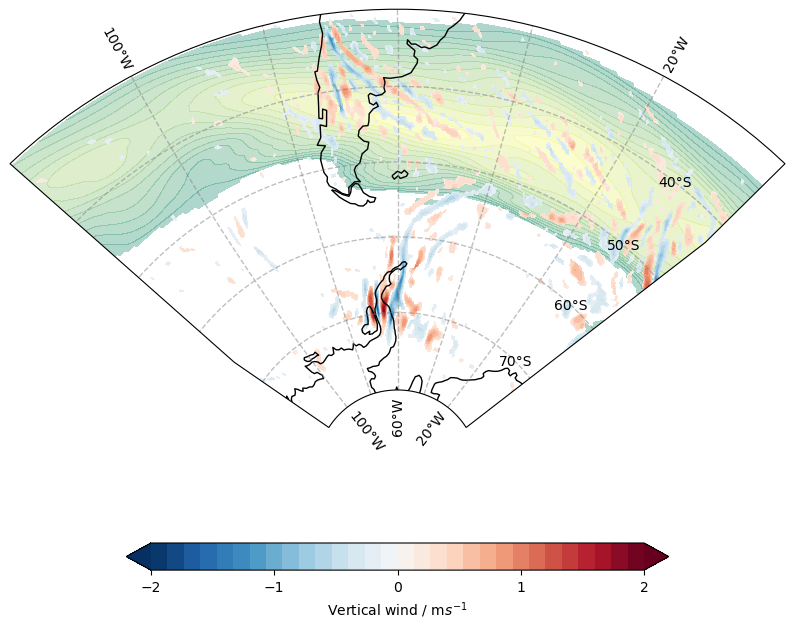

In [22]:
time_index = 1
z0 = 50_000
da = pert['w'].isel(time=time_index).sel(alt=z0,method='nearest')
da_u = pert['u_bg'].isel(time=time_index).sel(alt=z0,method='nearest')

# Define the geografic region that is under investigation.
lonW = -120
lonE = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev   = np.linspace(-2,2,31)
clon    = (lonW+lonE)/2
clat    = (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path    = watson.nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

fig=plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels  = True  # Hide labels on the right side
gridlines.left_labels   = True  # Hide labels on the right side
gridlines.top_labels    = False # Hide labels on the top
gridlines.bottom_labels = True  # Hide labels on the top

masked = np.ma.masked_outside(da_u.sel(lat=slice(extent_SP[2],extent_SP[3])), 70, 140)  
plot_u = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=np.linspace(70,140,15),extend='both',cmap='summer',alpha=0.33)
masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [4]:
# Define Box of interest
ds_box  = pert.sel(lon=slice(-75,-55),lat=slice(-75,-60)).isel(time=1)
cart_ds = robfft.lonlat_to_cartesian_grid(ds_box, lon="lon", lat="lat")
rob_res = robfft.get_wave_parameters(cart_ds,'w',dim_x='x',dim_y='y',dim_z='alt',tapering=True,lat_mean=-67.5)

<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/scratch-local/slurm-job-tmp-13259471/ipykernel_799/2939997027.py:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])


Text(0, 0.5, '$k_y$ / $km^{-1}$')

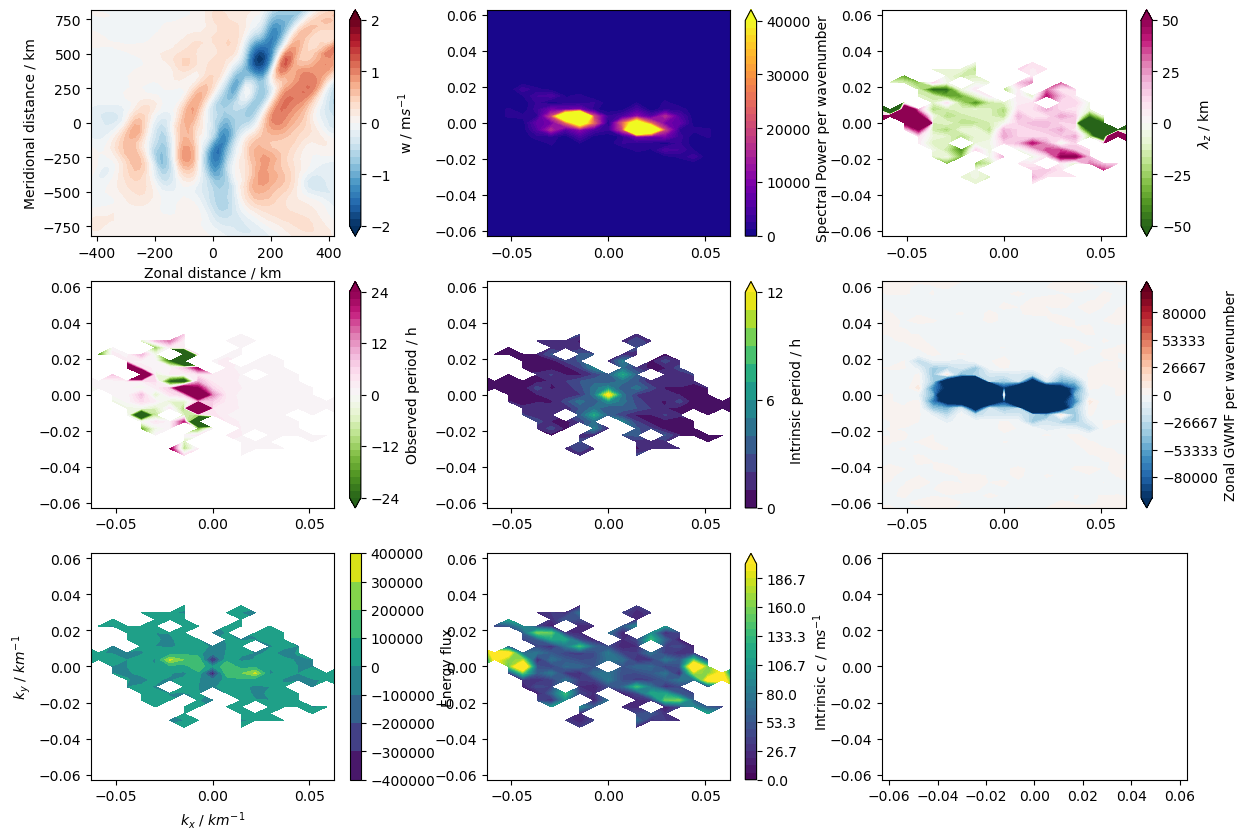

In [43]:
z0 = 40_000
MF_threshold = 1_000

power      = rob_res['spectral_power'].sel(alt=z0, method='nearest').T
lz_field   = 2*np.pi/rob_res['m'].sel(alt=z0, method='nearest').T*1e-3
tau_field  = 2*np.pi/rob_res['omega_shifted'].sel(alt=z0, method='nearest').T/3_600
taui_field = 2*np.pi/rob_res['omega'].sel(alt=z0, method='nearest').T/3_600
MF_field   = rob_res['uw'].sel(alt=z0, method='nearest').T
EF_field   = rob_res['pw'].sel(alt=z0, method='nearest').T
KX, KY  = np.meshgrid(rob_res.kx, rob_res.ky)
K_ABS   = np.sqrt(KX**2+KY**2)
c_field = rob_res['omega'].sel(alt=z0, method='nearest').T/K_ABS

rows, colm = watson.define_grid(7)

gskw = {"hspace": 0.2, "wspace": 0.3, "width_ratios": colm*[1], "height_ratios": rows*[1]}
fig, axes = plt.subplots(rows,colm,figsize=(10*1.414,10), sharey=False, sharex=False, gridspec_kw=gskw)

plot_w = axes[0,0].contourf(cart_ds.x*1e-3,cart_ds.y*1e-3,cart_ds['w'].sel(alt=z0,method='nearest'),levels=np.linspace(-2,2,31),cmap='RdBu_r',extend='both')
cbar   = fig.colorbar(plot_w,label='w / m$s^{-1}$',ticks=[-2,-1,0,1,2])

plot_spectrum = axes[0,1].contourf(rob_res.kx*1e3,rob_res.ky*1e3,power,levels=np.linspace(0,40_000,31),cmap='plasma',extend='max')
cbar          = fig.colorbar(plot_spectrum,label='Spectral Power per wavenumber',ticks=[0,10_000,20_000,30_000,40_000])

lz_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, lz_field)
plot_lz   = axes[0,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, lz_masked, levels=np.linspace(-50,50,31),cmap='PiYG_r',extend='both')
cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])

tau_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, tau_field)
plot_tau   = axes[1,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, tau_masked, levels=np.linspace(-24,24,31),extend='both',cmap='PiYG_r')
cbar       = fig.colorbar(plot_tau, label='Observed period / h', ticks=[-24,-12,0,12,24])

taui_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, taui_field)
plot_taui   = axes[1,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, taui_masked, levels=np.linspace(0,12,13),extend='max')
cbar        = fig.colorbar(plot_taui, label='Intrinsic period / h', ticks=[0,6,12])

plot_MF = axes[1,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, MF_field, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar    = fig.colorbar(plot_MF, label='Zonal GWMF per wavenumber')

EF_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, EF_field)
plot_EF   = axes[2,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, EF_masked)
cbar      = fig.colorbar(plot_EF, label='Energy flux')

c_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, c_field)
plot_c = axes[2,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, c_masked, levels=np.linspace(0,200,31), extend='max')
cbar   = fig.colorbar(plot_c, label='Intrinsic c / m$s^{-1}$')

xlim0=[-2*np.pi/100,2*np.pi/100]
xlim=[[cart_ds.x[0]*1e-3,cart_ds.x[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
ylim=[[cart_ds.y[0]*1e-3,cart_ds.y[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
for i in range(rows):
    for j in range(colm):
        axes[i,j].set_xlim(xlim[j+i*rows])
        axes[i,j].set_ylim(ylim[j+i*rows])

axes[0,0].set_xlabel('Zonal distance / km')
axes[0,0].set_ylabel('Meridional distance / km')
axes[2,0].set_xlabel('$k_x$ / $km^{-1}$')
axes[2,0].set_ylabel('$k_y$ / $km^{-1}$')

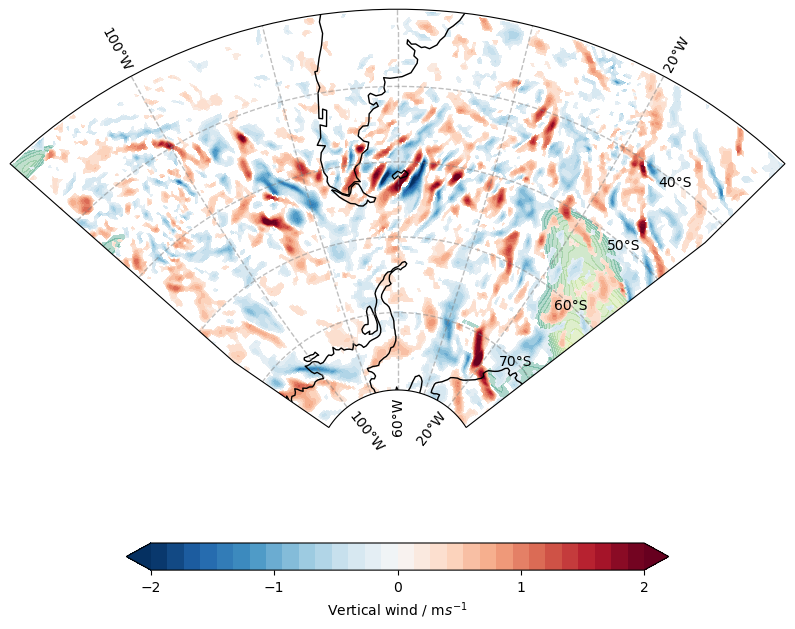

In [44]:
time_index = 1
z0 = 100_000
da = pert['w'].isel(time=time_index).sel(alt=z0,method='nearest')
da_u = pert['u_bg'].isel(time=time_index).sel(alt=z0,method='nearest')

# Define the geografic region that is under investigation.
lonW = -120
lonE = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev   = np.linspace(-2,2,31)
clon    = (lonW+lonE)/2
clat    = (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path    = watson.nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

fig=plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels  = True  # Hide labels on the right side
gridlines.left_labels   = True  # Hide labels on the right side
gridlines.top_labels    = False # Hide labels on the top
gridlines.bottom_labels = True  # Hide labels on the top

masked = np.ma.masked_outside(da_u.sel(lat=slice(extent_SP[2],extent_SP[3])), 70, 140)  
plot_u = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=np.linspace(70,140,15),extend='both',cmap='summer',alpha=0.33)
masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [45]:
# Define Box of interest
ds_box  = pert.sel(lon=slice(-80,-40),lat=slice(-60,-40)).isel(time=1)
cart_ds = robfft.lonlat_to_cartesian_grid(ds_box, lon="lon", lat="lat")
rob_res = robfft.get_wave_parameters(cart_ds,'w',dim_x='x',dim_y='y',dim_z='alt',tapering=True,lat_mean=-50)

<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/scratch-local/slurm-job-tmp-13259471/ipykernel_799/3189559249.py:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])


Text(0, 0.5, '$k_y$ / $km^{-1}$')

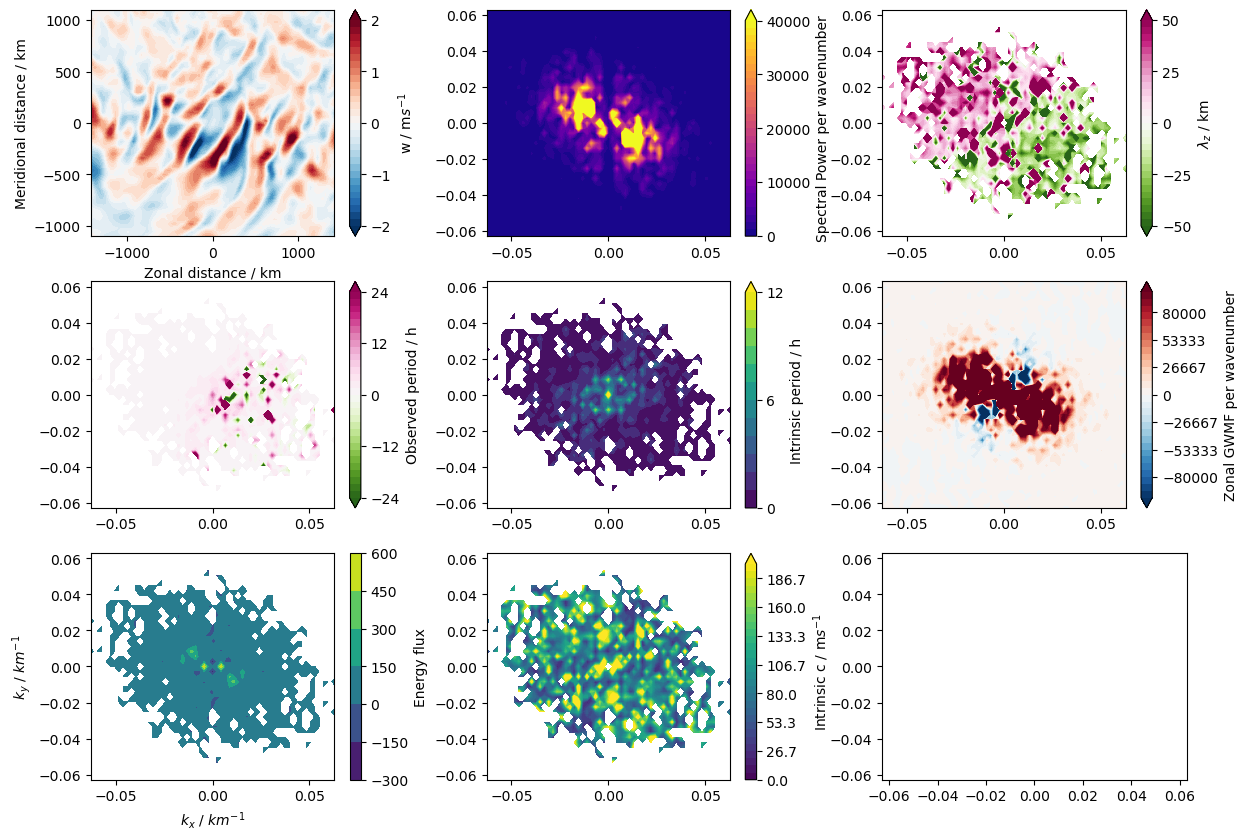

In [48]:
z0 = 99_500
MF_threshold = 1_000

power      = rob_res['spectral_power'].sel(alt=z0, method='nearest').T
lz_field   = 2*np.pi/rob_res['m'].sel(alt=z0, method='nearest').T*1e-3
tau_field  = 2*np.pi/rob_res['omega_shifted'].sel(alt=z0, method='nearest').T/3_600
taui_field = 2*np.pi/rob_res['omega'].sel(alt=z0, method='nearest').T/3_600
MF_field   = rob_res['uw'].sel(alt=z0, method='nearest').T
EF_field   = rob_res['pw'].sel(alt=z0, method='nearest').T
KX, KY  = np.meshgrid(rob_res.kx, rob_res.ky)
K_ABS   = np.sqrt(KX**2+KY**2)
c_field = rob_res['omega'].sel(alt=z0, method='nearest').T/K_ABS

rows, colm = watson.define_grid(7)

gskw = {"hspace": 0.2, "wspace": 0.3, "width_ratios": colm*[1], "height_ratios": rows*[1]}
fig, axes = plt.subplots(rows,colm,figsize=(10*1.414,10), sharey=False, sharex=False, gridspec_kw=gskw)

plot_w = axes[0,0].contourf(cart_ds.x*1e-3,cart_ds.y*1e-3,cart_ds['w'].sel(alt=z0,method='nearest'),levels=np.linspace(-2,2,31),cmap='RdBu_r',extend='both')
cbar   = fig.colorbar(plot_w,label='w / m$s^{-1}$',ticks=[-2,-1,0,1,2])

plot_spectrum = axes[0,1].contourf(rob_res.kx*1e3,rob_res.ky*1e3,power,levels=np.linspace(0,40_000,31),cmap='plasma',extend='max')
cbar          = fig.colorbar(plot_spectrum,label='Spectral Power per wavenumber',ticks=[0,10_000,20_000,30_000,40_000])

lz_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, lz_field)
plot_lz   = axes[0,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, lz_masked, levels=np.linspace(-50,50,31),cmap='PiYG_r',extend='both')
cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])

tau_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, tau_field)
plot_tau   = axes[1,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, tau_masked, levels=np.linspace(-24,24,31),extend='both',cmap='PiYG_r')
cbar       = fig.colorbar(plot_tau, label='Observed period / h', ticks=[-24,-12,0,12,24])

taui_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, taui_field)
plot_taui   = axes[1,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, taui_masked, levels=np.linspace(0,12,13),extend='max')
cbar        = fig.colorbar(plot_taui, label='Intrinsic period / h', ticks=[0,6,12])

plot_MF = axes[1,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, MF_field, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar    = fig.colorbar(plot_MF, label='Zonal GWMF per wavenumber')

EF_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, EF_field)
plot_EF   = axes[2,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, EF_masked)
cbar      = fig.colorbar(plot_EF, label='Energy flux')

c_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, c_field)
plot_c = axes[2,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, c_masked, levels=np.linspace(0,200,31), extend='max')
cbar   = fig.colorbar(plot_c, label='Intrinsic c / m$s^{-1}$')

xlim0=[-2*np.pi/100,2*np.pi/100]
xlim=[[cart_ds.x[0]*1e-3,cart_ds.x[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
ylim=[[cart_ds.y[0]*1e-3,cart_ds.y[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
for i in range(rows):
    for j in range(colm):
        axes[i,j].set_xlim(xlim[j+i*rows])
        axes[i,j].set_ylim(ylim[j+i*rows])

axes[0,0].set_xlabel('Zonal distance / km')
axes[0,0].set_ylabel('Meridional distance / km')
axes[2,0].set_xlabel('$k_x$ / $km^{-1}$')
axes[2,0].set_ylabel('$k_y$ / $km^{-1}$')

<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/scratch-local/slurm-job-tmp-13259471/ipykernel_799/581074622.py:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])


Text(0, 0.5, '$k_y$ / $km^{-1}$')

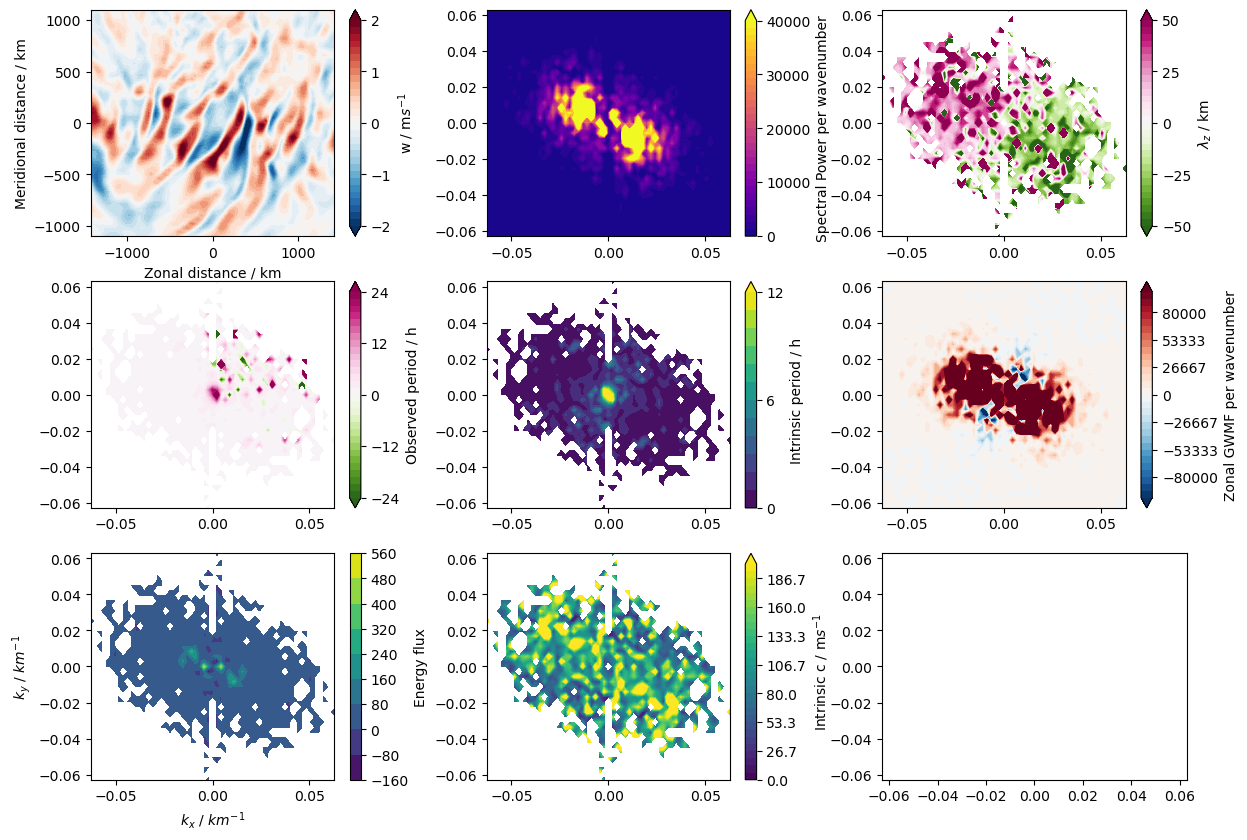

In [49]:
z0 = 101_300
MF_threshold = 1_000

power      = rob_res['spectral_power'].sel(alt=z0, method='nearest').T
lz_field   = 2*np.pi/rob_res['m'].sel(alt=z0, method='nearest').T*1e-3
tau_field  = 2*np.pi/rob_res['omega_shifted'].sel(alt=z0, method='nearest').T/3_600
taui_field = 2*np.pi/rob_res['omega'].sel(alt=z0, method='nearest').T/3_600
MF_field   = rob_res['uw'].sel(alt=z0, method='nearest').T
EF_field   = rob_res['pw'].sel(alt=z0, method='nearest').T
KX, KY  = np.meshgrid(rob_res.kx, rob_res.ky)
K_ABS   = np.sqrt(KX**2+KY**2)
c_field = rob_res['omega'].sel(alt=z0, method='nearest').T/K_ABS

rows, colm = watson.define_grid(7)

gskw = {"hspace": 0.2, "wspace": 0.3, "width_ratios": colm*[1], "height_ratios": rows*[1]}
fig, axes = plt.subplots(rows,colm,figsize=(10*1.414,10), sharey=False, sharex=False, gridspec_kw=gskw)

plot_w = axes[0,0].contourf(cart_ds.x*1e-3,cart_ds.y*1e-3,cart_ds['w'].sel(alt=z0,method='nearest'),levels=np.linspace(-2,2,31),cmap='RdBu_r',extend='both')
cbar   = fig.colorbar(plot_w,label='w / m$s^{-1}$',ticks=[-2,-1,0,1,2])

plot_spectrum = axes[0,1].contourf(rob_res.kx*1e3,rob_res.ky*1e3,power,levels=np.linspace(0,40_000,31),cmap='plasma',extend='max')
cbar          = fig.colorbar(plot_spectrum,label='Spectral Power per wavenumber',ticks=[0,10_000,20_000,30_000,40_000])

lz_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, lz_field)
plot_lz   = axes[0,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, lz_masked, levels=np.linspace(-50,50,31),cmap='PiYG_r',extend='both')
cbar      = fig.colorbar(plot_lz, label='$\lambda_z$ / km', ticks=[-50,-25,0,25,50])

tau_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, tau_field)
plot_tau   = axes[1,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, tau_masked, levels=np.linspace(-24,24,31),extend='both',cmap='PiYG_r')
cbar       = fig.colorbar(plot_tau, label='Observed period / h', ticks=[-24,-12,0,12,24])

taui_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, taui_field)
plot_taui   = axes[1,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, taui_masked, levels=np.linspace(0,12,13),extend='max')
cbar        = fig.colorbar(plot_taui, label='Intrinsic period / h', ticks=[0,6,12])

plot_MF = axes[1,2].contourf(rob_res.kx*1e3, rob_res.ky*1e3, MF_field, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar    = fig.colorbar(plot_MF, label='Zonal GWMF per wavenumber')

EF_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, EF_field)
plot_EF   = axes[2,0].contourf(rob_res.kx*1e3, rob_res.ky*1e3, EF_masked)
cbar      = fig.colorbar(plot_EF, label='Energy flux')

c_masked = np.ma.masked_where(np.abs(MF_field) <= MF_threshold, c_field)
plot_c = axes[2,1].contourf(rob_res.kx*1e3, rob_res.ky*1e3, c_masked, levels=np.linspace(0,200,31), extend='max')
cbar   = fig.colorbar(plot_c, label='Intrinsic c / m$s^{-1}$')

xlim0=[-2*np.pi/100,2*np.pi/100]
xlim=[[cart_ds.x[0]*1e-3,cart_ds.x[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
ylim=[[cart_ds.y[0]*1e-3,cart_ds.y[-1]*1e-3],xlim0,xlim0,
      xlim0,xlim0,xlim0,
      xlim0,xlim0,xlim0]
for i in range(rows):
    for j in range(colm):
        axes[i,j].set_xlim(xlim[j+i*rows])
        axes[i,j].set_ylim(ylim[j+i*rows])

axes[0,0].set_xlabel('Zonal distance / km')
axes[0,0].set_ylabel('Meridional distance / km')
axes[2,0].set_xlabel('$k_x$ / $km^{-1}$')
axes[2,0].set_ylabel('$k_y$ / $km^{-1}$')

In [ ]:
time_index = 1
da = ds['w'].isel(time=time_index).sel(alt=100_000,method='nearest')
da_u = ds['u'].isel(time=time_index).sel(alt=100_000,method='nearest')

# Define the geografic region that is under investigation.
lonW    = -120
lonE    = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev = np.linspace(-2,2,31)
u_lev = np.linspace(0,150,31)
fig=plt.figure(figsize=(10,10))
clon, clat = (lonW+lonE)/2, (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path = nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels = True  # Hide labels on the right side
gridlines.left_labels = True  # Hide labels on the right side
gridlines.top_labels = False    # Hide labels on the top
gridlines.bottom_labels = True    # Hide labels on the top

masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

wind = np.sqrt((u_12h_tide['mean_fit']+u_12h_tide['tide'].isel(time=time_index))**2+(v_12h_tide['mean_fit']+v_12h_tide['tide'].isel(time=time_index))**2)
masked = np.ma.masked_inside(wind, 0, 5) 
plot_wind = plt.contourf(ds.lon,ds.lat,masked,transform=ccrs.PlateCarree(),levels=np.linspace(5,100,20),extend='both',cmap='plasma',alpha=0.2)
LON, LAT = np.meshgrid(ds.lon, ds.lat)
plt.quiver(LON[::10,::10],LAT[::10,::10],masked[::10,::10],transform=ccrs.PlateCarree())
#masked = np.ma.masked_outside(v_12h_tide['mean_fit']+v_12h_tide['tide'].isel(time=time_index), -50, -5) 
#plot_u = plt.contourf(ds.lon,ds.lat,masked,transform=ccrs.PlateCarree(),levels=np.linspace(-50,-5,5),extend='both',cmap='viridis',alpha=0.2)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")